# Universidade Europeia
# Mestrado em Ciência de Dados e Gestão

# TG1 — Regressão Linear e Previsão

## 1. Seleção do Conjunto de Dados

**Fonte:** UCI Machine Learning Repository — *Wine Quality Dataset*  
**URL:** https://archive.ics.uci.edu/ml/datasets/wine+quality

**Contexto:**  
O conjunto de dados contém informações físico-químicas de amostras de vinho tinto e vinho branco português (Vinho Verde), recolhidas entre 2004 e 2007. Cada amostra foi avaliada sensorialmente por pelo menos três especialistas, que atribuíram uma pontuação de qualidade entre 0 (muito mau) e 10 (excelente).

**Variáveis:**  
O dataset possui **11 variáveis explicativas contínuas**: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates e alcohol. A variável resposta é **quality** (pontuação de 0 a 10).

**Objetivo de previsão:**  
Prever a qualidade sensorial de um vinho com base nas suas propriedades físico-químicas mensuráveis, o que pode ser útil para produtores que pretendam otimizar os processos de produção sem recorrer a painéis de degustação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

sns.set_style("whitegrid")

In [2]:
# Carregar os datasets
df_red = pd.read_csv("winequality-red.csv", sep=';')
df_white = pd.read_csv("winequality-white.csv", sep=';')

# Juntar os datasets com coluna identificadora do tipo de vinho
df_red["type"] = "red"
df_white["type"] = "white"
df = pd.concat([df_red, df_white], ignore_index=True)

print(f"Dataset combinado: {df.shape[0]} observações, {df.shape[1]} variáveis")
df.head()

Dataset combinado: 6497 observações, 13 variáveis


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


---
## 2. Análise Exploratória

### 2.1 Resumos Estatísticos

In [4]:
# Informação geral sobre o dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [3]:
# Resumo estatístico das variáveis contínuas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,1.292975,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,4.821671,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,100.369000,4.010000,2.000000,14.900000,9.000000


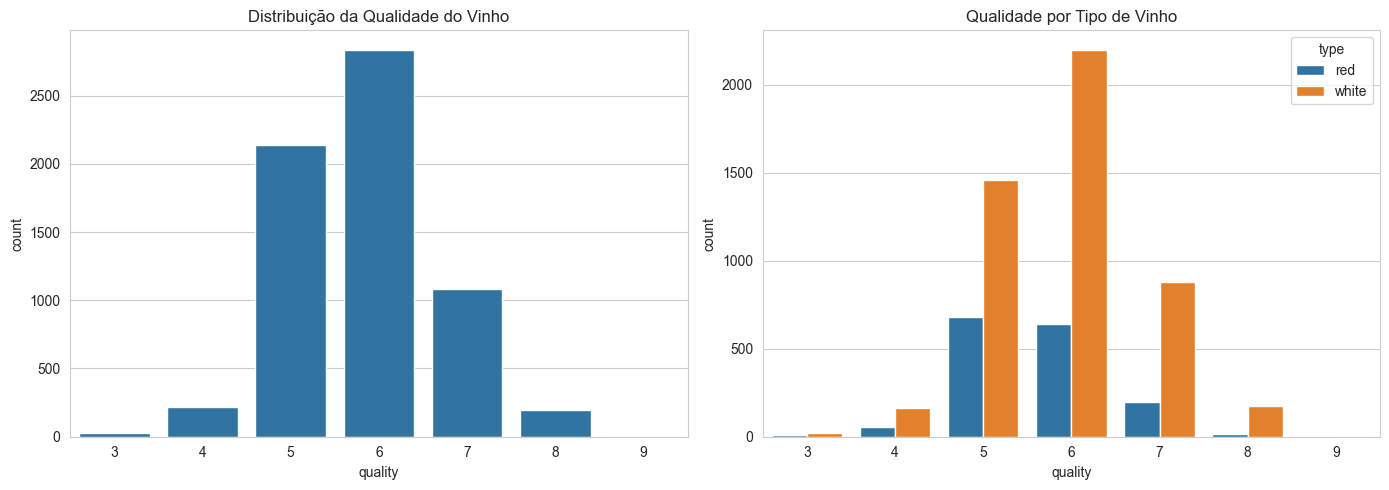

In [6]:
# Distribuição da qualidade geral e por tipo de vinho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="quality", data=df, ax=axes[0])
axes[0].set_title("Distribuição da Qualidade do Vinho")

sns.countplot(x="quality", hue="type", data=df, ax=axes[1])
axes[1].set_title("Qualidade por Tipo de Vinho")

plt.tight_layout()
plt.show()

### 2.2 Análise de Correlações

In [7]:
# Matriz de correlação numérica
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.225610,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.073411,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.037697,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.006270,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.104997,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,-0.023819,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,-0.064768,-0.238413,-0.275727,-0.265740,-0.041385
density,0.225610,0.073411,0.037697,0.006270,0.104997,-0.023819,-0.064768,1.000000,-0.023488,0.079997,-0.030790,-0.024900
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,-0.023488,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.079997,0.192123,1.000000,-0.003029,0.038485


A escolha destas duas e não outras

**alcohol (r = +0.444)** — é de longe a variável com correlação mais forte com quality. Sinal positivo: mais álcool, melhor qualidade. Faz sentido enologicamente — vinhos mais alcoólicos tendem a ser mais encorpados e melhor avaliados.

**volatile acidity (r = −0.266)** — é a correlação negativa mais forte. Sinal negativo: mais acidez volátil, pior qualidade. Também faz sentido — a acidez volátil elevada confere sabor a vinagre, degradando a avaliação.

As restantes têm correlações abaixo de ±0.21, o que indica relações lineares muito fracas — não adequadas para modelar com regressão linear simples.

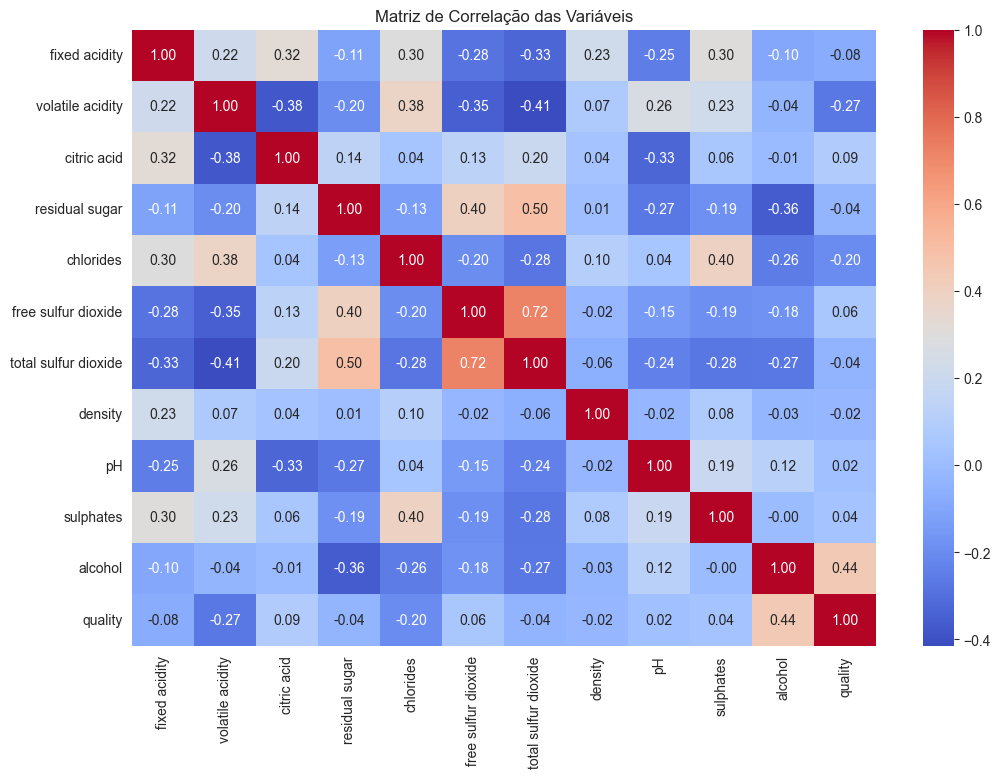

In [8]:
# Heatmap da matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis")
plt.show()

**Guia de leitura do heatmap**

**Vermelho escuro (1.00)** correlação positiva forte, quando uma variável sobe, a outra também sobe

**Cinza (0.00)** sem relação linear, as variáveis são independentes entre si

**Azul escuro (−0.4)** correlação negativa forte, quando uma sobe, a outra desce

O mapa é simétrico: a correlação entre alcohol e quality (0.44) é a mesma que entre quality e alcohol (0.44). Por isso o triângulo de cima e o de baixo da diagonal são espelhos, pode ser lido em qualquer direção.

In [9]:
# Correlações com a variável resposta (quality), ordenadas
corr_matrix["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
density                -0.024900
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
Name: quality, dtype: float64

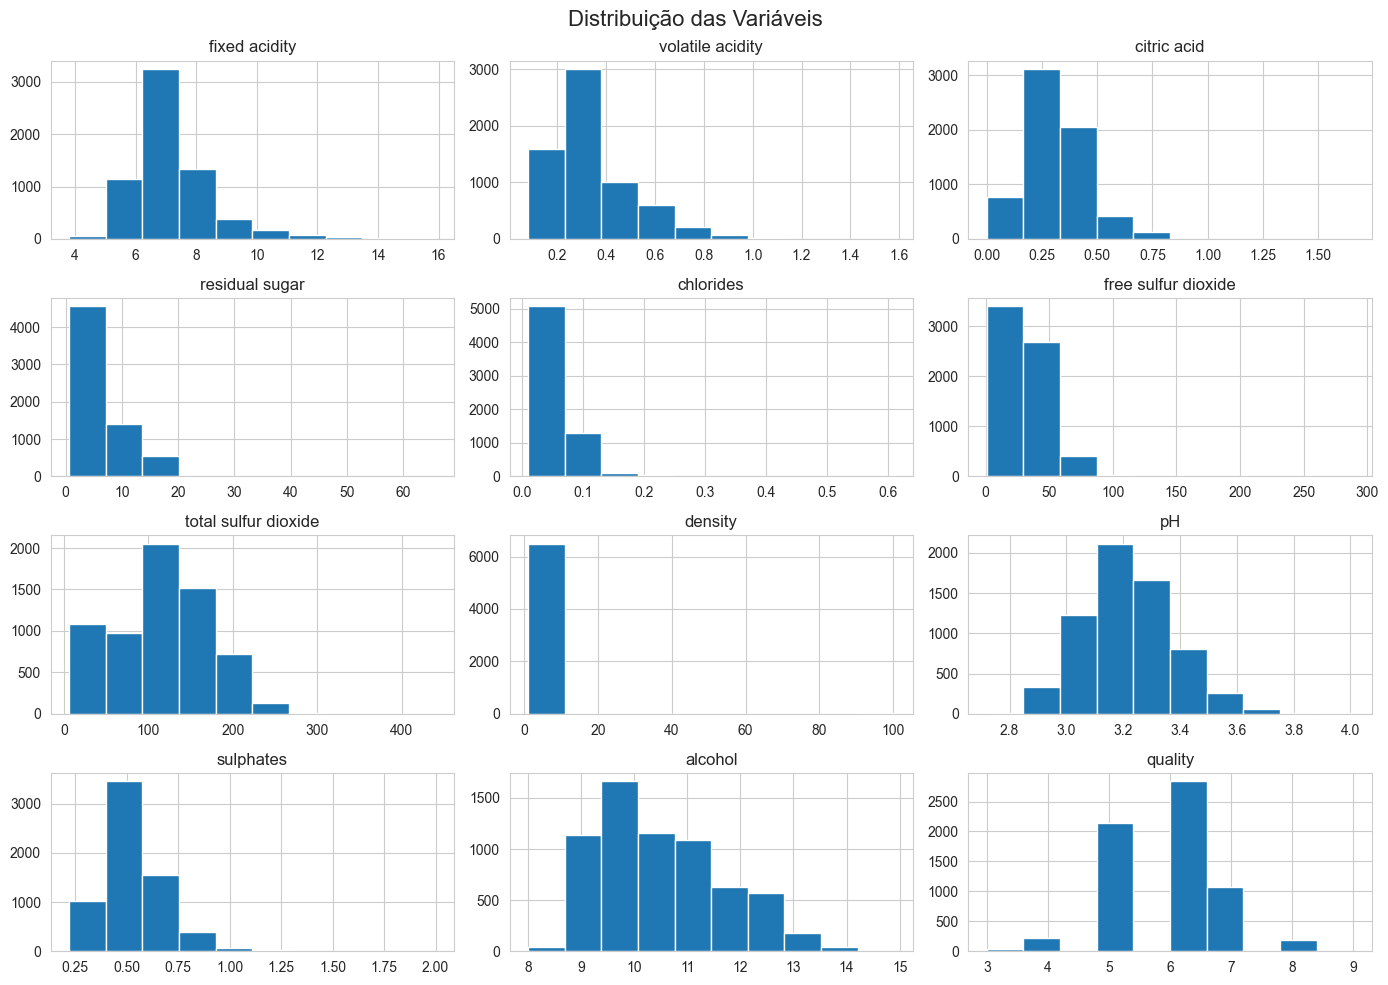

In [10]:
# Histogramas de todas as variáveis contínuas
df.hist(figsize=(14, 10))
plt.suptitle("Distribuição das Variáveis", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretação dos histogramas:**

**alcohol — variável X do Modelo 1**
O histograma mostra que a maioria dos vinhos tem entre 9% e 12% de álcool, com pico à volta dos 9-10%. A distribuição tem uma ligeira cauda à direita — há poucos vinhos muito alcoólicos (13-14%). O intervalo vai de 8% a quase 15%. Isto confirma o que o **df.describe()** mostra: Q1=9.5%, mediana=10.3%, Q3=11.3%.

**volatile acidity — variável X do Modelo 2**
Forte cauda à direita — a maioria dos vinhos tem acidez volátil baixa (0.1–0.4 g/L), mas existe um rabo com valores até 1.6 g/L. Esses vinhos com acidez muito alta são os que têm sabor a vinagre, e são os que mais puxam o β₁ para baixo na regressão.

**quality — variável resposta Y**
Distribuição muito concentrada em 5 e 6. É uma variável discreta — as barras estão separadas porque os valores só são inteiros. Isto é relevante para os resíduos: como Y só toma valores inteiros, os resíduos também ficam agrupados, o que explica o ligeiro desvio nas caudas do QQ Plot.

**residual sugar e chlorides — distribuições com outliers**
Ambas têm caudas muito longas à direita. O residual sugar chega a 65 g/L mas a maioria está abaixo de 20. Os chlorides chegam a 0.6 mas a maioria está abaixo de 0.1. Isto indica a presença de outliers, valores extremos que se afastam muito da maioria. Por isso não foi escolhido para a regressão, a relação não seria linear.

**density — a distribuição mais estranha**
O eixo X vai de 0 a 100 mas quase todos os vinhos estão na primeira barra — porque a densidade do vinho é aproximadamente 1.0 g/cm³ e a escala foi mal ajustada no gráfico. Isto acontece porque existe um outlier extremo no dataset (density = 100) que distorce a escala.

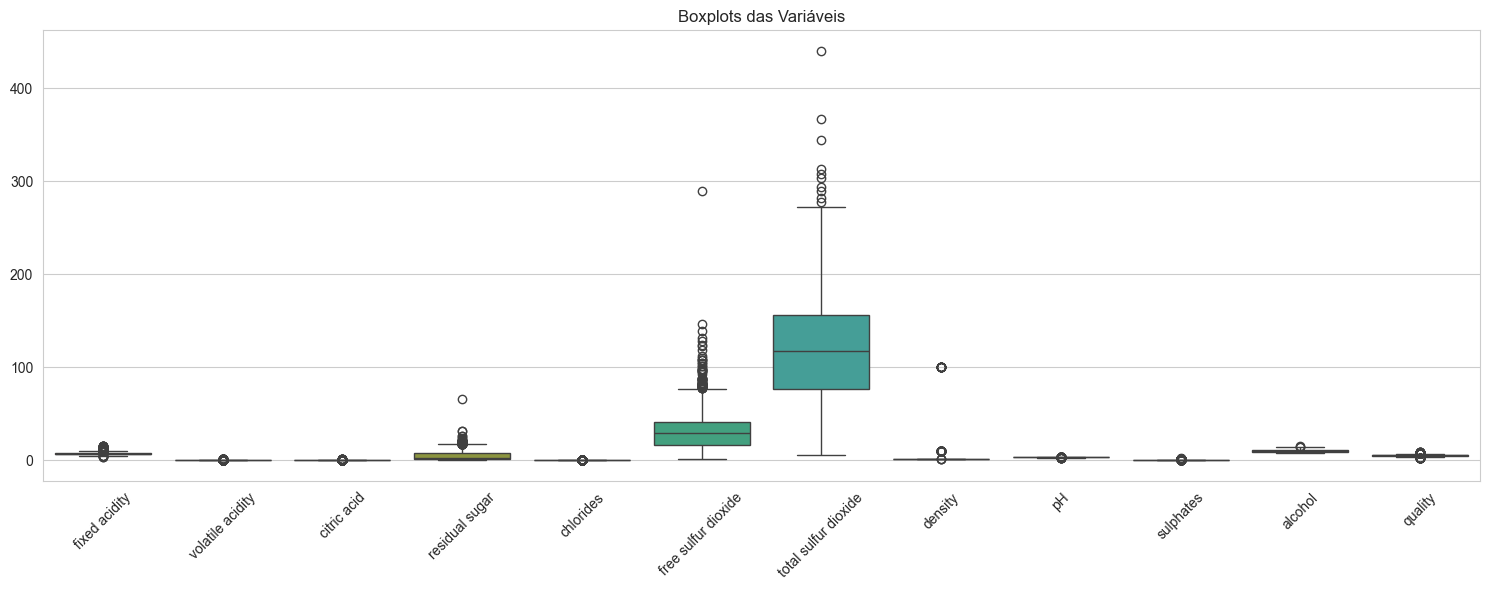

In [11]:
# Boxplots para identificar outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=df.drop("type", axis=1))
plt.title("Boxplots das Variáveis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretação dos outliers**

**total sulfur dioxide** — caixa grande, muitos outliers
É a variável com maior amplitude. A caixa vai de ~77 a ~156, com mediana ~118. Tem muitos outliers acima dos 280 — alguns chegam a 440.

**free sulfur dioxide** — também com outliers visíveis
Caixa mais pequena que o total SO₂ mas com vários outliers bem visíveis acima dos 100, chegando a ~290. A caixa está concentrada entre ~17 e ~41.

**residual sugar** — outlier muito visível
Há um outlier claramente visível acima de 60 g/L, muito afastado da caixa. A caixa em si está muito comprimida no fundo, a maioria dos vinhos tem pouquíssimo açúcar residual.

**alcohol e quality** — as variáveis escolhidas
Ambas têm caixas muito pequenas por causa da escala dominada pelo SO₂. A quality tem a caixa muito comprimida, confirma a concentração em 5-6. Nenhuma das duas tem outliers extremos visíveis.

**density** — o círculo isolado a ~100
Um único círculo isolado a ~100, muito afastado de todos os outros. Esse é o outlier extremo que distorceu o histograma da density. Toda a caixa real da density está comprimida perto do zero na escala deste gráfico, porque a densidade real dos vinhos é ~0.99 g/cm³.

### 2.3 Diagramas de Dispersão e Escolha das Relações

Com base na análise da matriz de correlação, as variáveis com correlação mais forte com `quality` são:
- **alcohol** (r ≈ +0.44): correlação positiva moderada — vinhos com maior teor alcoólico tendem a ter melhor avaliação sensorial.
- **volatile acidity** (r ≈ −0.27): correlação negativa — o aumento da acidez volátil (vinagre) degrada a qualidade percebida.

Estas duas relações são as mais adequadas para modelar com regressão linear simples, pois apresentam a correlação linear mais expressiva com a variável resposta e têm interpretação física plausível no contexto da enologia.

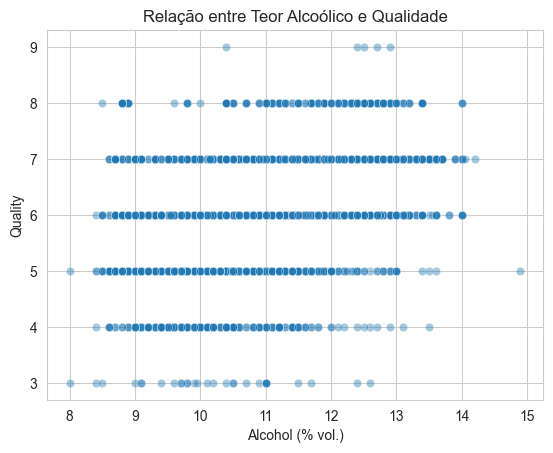

In [4]:
# Diagrama de dispersão — Relação 1: alcohol vs quality
sns.scatterplot(x="alcohol", y="quality", data=df, alpha=0.4)
plt.title("Relação entre Teor Alcoólico e Qualidade")
plt.xlabel("Alcohol (% vol.)")
plt.ylabel("Quality")
plt.show()

**4 observações:**

Cada ponto é um vinho. A posição horizontal mostra o seu teor alcoólico, a posição vertical mostra a sua qualidade.
 
1. Os pontos formam linhas horizontais
Porque a quality é uma variável discreta, só toma valores inteiros. Por isso os pontos estão alinhados em 7 linhas horizontais e não numa nuvem contínua. 

2. A tendência geral é positiva — a nuvem sobe da esquerda para a direita
Nas linhas de qualidade 3 e 4, os pontos concentram-se mais à esquerda, álcool baixo. Nas linhas de qualidade 7, 8 e 9, os pontos deslocam-se para a direita, álcool mais alto. Esta é a relação positiva que justifica r = +0.444.

3. Há muita sobreposição — especialmente na qualidade 5 e 6
As linhas do 5 e do 6 têm pontos muito escuros e densos, são os mais frequentes. E espalham-se por toda a gama de álcool, de 8% a 14%. Isto explica por que o R² não é alto, dentro de cada nível de qualidade, há vinhos com álcool muito variado.

4. Qualidade 9 — apenas 3 pontos visíveis, todos com álcool alto
A linha do 9 tem pouquíssimos pontos, todos acima dos 11%. Confirma que vinhos de qualidade extrema são raros no dataset e têm alto teor alcoólico, mas com tão poucos casos, o modelo tem dificuldade em aprender este padrão.

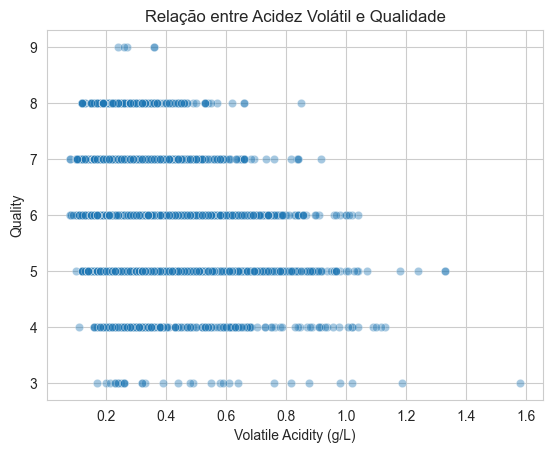

In [13]:
# Diagrama de dispersão — Relação 2: volatile acidity vs quality
sns.scatterplot(x="volatile acidity", y="quality", data=df, alpha=0.4)
plt.title("Relação entre Acidez Volátil e Qualidade")
plt.xlabel("Volatile Acidity (g/L)")
plt.ylabel("Quality")
plt.show()

4 observações:

1. A tendência é negativa — a nuvem desce da esquerda para a direita
As linhas de qualidade 7, 8 e 9 têm pontos concentrados à esquerda — acidez baixa (0.1–0.5 g/L). As linhas de qualidade 3, 4 e 5 estendem-se mais para a direita — acidez mais alta. Quanto mais acidez volátil, pior a qualidade. Esta é a relação negativa que justifica r = −0.266.

2. A maioria dos pontos concentra-se entre 0.1 e 0.6 g/L
As barras mais densas estão do lado esquerdo. A grande maioria dos vinhos tem acidez volátil baixa, independentemente da qualidade.

3. Acima de 1.0 g/L os pontos são quase todos de qualidade baixa
A partir de 1.0 g/L, praticamente só existem vinhos de qualidade 3, 4 e 5. O único ponto de qualidade 3 a 1.6 g/L é o outlier extremo, o vinho com mais vinagre do dataset.

4. Qualidade 9 — dois pontos, ambos com acidez muito baixa
Os dois pontos de qualidade 9 estão ambos abaixo de 0.3 g/L — confirmando que os melhores vinhos têm acidez volátil muito baixa. Faz sentido enologicamente.

---
## 3. Ajuste do Modelo de Regressão

### 3.1 Relação 1: Quality em função de Alcohol

In [14]:
# Preparar variáveis
X = df[["alcohol"]]
y = df["quality"]

# Ajustar o modelo
model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]
r2 = model.score(X, y)

print(f"Equação estimada: quality = {intercept:.4f} + {slope:.4f} × alcohol")
print(f"R² = {r2:.4f}")

Equação estimada: quality = 2.4053 + 0.3253 × alcohol
R² = 0.1974


**Interpretação dos coeficientes — Relação 1:**

**β₀ = 2.4053 — o intercepto**

É o valor previsto de quality quando alcohol = 0%. Matematicamente é onde a reta corta o eixo Y. Não tem interpretação prática — nenhum vinho tem 0% de álcool. Serve apenas para posicionar a reta corretamente.

**β₁ = +0.3253 — o declive**

Por cada +1% de álcool, a qualidade prevista sobe em média +0.3253 pontos.

Exemplo:
- Vinho com 10% de álcool → quality prevista = 2.4053 + 0.3253 × 10 = 5.66
- Vinho com 11% de álcool → quality prevista = 2.4053 + 0.3253 × 11 = 5.98

**R² = 0.1974 — a qualidade do modelo**

O modelo explica 19.74% ≈ 20% da variação total da qualidade. Os restantes 80% ficam por explicar, dependem de outras variáveis não incluídas neste modelo simples.

In [15]:
# Verificar que a reta passa pelo ponto das médias

mean_x = X['alcohol'].mean()
mean_y = y.mean()
predicted_at_mean = intercept + slope * mean_x

print(f"Média de alcohol (X̄): {mean_x:.4f}")
print(f"Média de quality (Ȳ): {mean_y:.4f}")
print(f"Valor previsto em X̄: {predicted_at_mean:.4f}")
print(f"A reta passa pelo ponto das médias: {np.isclose(predicted_at_mean, mean_y, atol=1e-6)}")

Média de alcohol (X̄): 10.4918
Média de quality (Ȳ): 5.8184
Valor previsto em X̄: 5.8184
A reta passa pelo ponto das médias: True


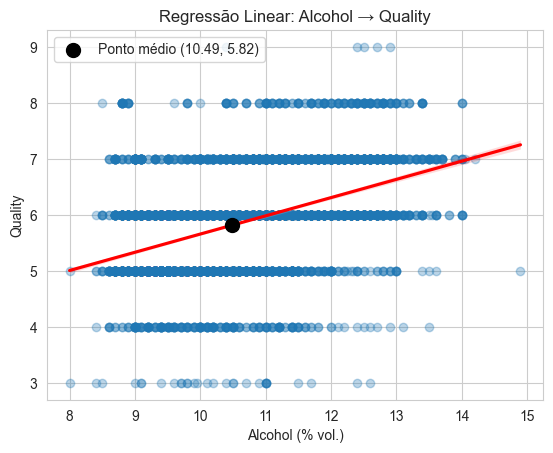

In [16]:
# Gráfico de regressão com ponto das médias assinalado
sns.regplot(x="alcohol", y="quality", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.scatter(mean_x, mean_y, color="black", zorder=5, s=100, label=f"Ponto médio ({mean_x:.2f}, {mean_y:.2f})")
plt.title("Regressão Linear: Alcohol → Quality")
plt.xlabel("Alcohol (% vol.)")
plt.ylabel("Quality")
plt.legend()
plt.show()

**Identificação dos elementos**

- Pontos azuis — representam cada vinho. O a cor é mais escura há mais vinhos sobrepostos. As linhas horizontais confirmam que quality é discreta.

- Reta vermelha — a regressão linear: quality = 2.4053 + 0.3253 × alcohol. Entra pelo canto inferior esquerdo (~5 em alcohol=8%) e sai pelo canto superior direito (~7.3 em alcohol=15%). 
Inclinação visível — confirma β₁ positivo.

- Ponto preto (10.49, 5.82) — o ponto das médias. X̄ = média do alcohol = 10.49%, Ȳ = média da quality = 5.82. A reta passa obrigatoriamente por este ponto — é uma garantia matemática da regressão linear.

O que a reta vermelha prevê — leitura direta do gráfico:
- ≈ 5.0
quality prevista
para alcohol = 8%
2.4053 + 0.3253×8

- 5.82
quality prevista
para alcohol = 10.49%
ponto das médias 

- ≈ 7.3
quality prevista
para alcohol = 15%
2.4053 + 0.3253×15

### 3.2 Relação 2: Quality em função de Volatile Acidity

In [17]:
# Preparar variáveis
X2 = df[["volatile acidity"]]
y2 = df["quality"]

# Ajustar o modelo
model2 = LinearRegression()
model2.fit(X2, y2)

intercept2 = model2.intercept_
slope2 = model2.coef_[0]
r2_2 = model2.score(X2, y2)

print(f"Equação estimada: quality = {intercept2:.4f} + ({slope2:.4f}) × volatile_acidity")
print(f"R² = {r2_2:.4f}")

Equação estimada: quality = 6.2971 + (-1.4093) × volatile_acidity
R² = 0.0706


**Interpretação dos dados**

- β₀ = 6.2971 — o intercepto
Qualidade prevista para um vinho com volatile acidity = 0 g/L — nenhum vinho tem zero acidez, por isso este valor não tem interpretação prática. Serve para posicionar a reta. 

- β₁ = −1.4093 — o declive negativo
Por cada +1 g/L de acidez volátil, a qualidade prevista cai em média −1.4093 pontos.

Exemplos:
- Vinho com 0.3 g/L → quality = 6.2971 − 1.4093 × 0.3 = 5.87
- Vinho com 0.6 g/L → quality = 6.2971 − 1.4093 × 0.6 = 5.45
- Vinho com 1.0 g/L → quality = 6.2971 − 1.4093 × 1.0 = 4.89
Quanto mais vinagre, pior a qualidade prevista. Faz todo o sentido enologicamente.

- R² = 0.0706 — apenas 7% explicado
A volatile acidity explica apenas 7% da variação da qualidade, é um ajuste fraco. Mas a direção e o efeito são corretos e têm sentido. O R² baixo não significa que o modelo está errado, significa que a acidez volátil sozinha não é suficiente para prever a qualidade.

In [18]:
# Verificar que a reta passa pelo ponto das médias
mean_x2 = X2['volatile acidity'].mean()
mean_y2 = y2.mean()
predicted_at_mean2 = intercept2 + slope2 * mean_x2

print(f"Média de volatile acidity (X̄): {mean_x2:.4f}")
print(f"Média de quality (Ȳ): {mean_y2:.4f}")
print(f"Valor previsto em X̄: {predicted_at_mean2:.4f}")
print(f"A reta passa pelo ponto das médias: {np.isclose(predicted_at_mean2, mean_y2, atol=1e-6)}")

Média de volatile acidity (X̄): 0.3397
Média de quality (Ȳ): 5.8184
Valor previsto em X̄: 5.8184
A reta passa pelo ponto das médias: True


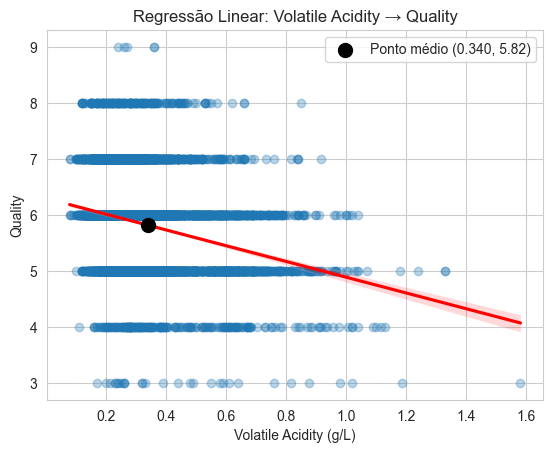

In [19]:
# Gráfico de regressão com ponto das médias assinalado
sns.regplot(x="volatile acidity", y="quality", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.scatter(mean_x2, mean_y2, color="black", zorder=5, s=100, label=f"Ponto médio ({mean_x2:.3f}, {mean_y2:.2f})")
plt.title("Regressão Linear: Volatile Acidity → Quality")
plt.xlabel("Volatile Acidity (g/L)")
plt.ylabel("Quality")
plt.legend()
plt.show()

**Interpretação dos 3 elementos do gráfico**

- Pontos azuis — cada vinho. A mancha mais densa está à esquerda (0.1–0.5 g/L) — confirma que a maioria dos vinhos tem acidez baixa.

- Reta vermelha — desce da esquerda para a direita. Começa em ~6.3 (quando acidity≈0) e desce até ~4.0 (quando acidity≈1.6). Inclinação negativa — confirma β₁ = −1.4093.

- Ponto preto (0.340, 5.82) — o ponto das médias. X̄ = 0.340 g/L (média da volatile acidity), Ȳ = 5.82 (média da quality). A reta passa obrigatoriamente aqui.

- A banda rosa é o intervalo de confiança a 95% 

### 3.3 Regressão Inversa: Alcohol em função de Quality

Para a Relação 1, ajusta-se também a regressão no sentido inverso (X em função de Y), e representam-se as duas retas no mesmo gráfico.

In [20]:
# Regressão inversa: alcohol ~ quality
X_inv = df[["quality"]]
y_inv = df["alcohol"]
model_inv = LinearRegression()
model_inv.fit(X_inv, y_inv)

intercept_inv = model_inv.intercept_
slope_inv = model_inv.coef_[0]
r2_inv = model_inv.score(X_inv, y_inv)

print(f"Equação inversa: alcohol = {intercept_inv:.4f} + {slope_inv:.4f} × quality")
print(f"R² (inverso) = {r2_inv:.4f}")

Equação inversa: alcohol = 6.9609 + 0.6069 × quality
R² (inverso) = 0.1974


**Interpretação**

A regressão inversa deu alcohol = 6.9609 + 0.6069 x quality. O R quadrado é 0.1974, igual ao Modelo 1, o que é esperado porque o R quadrado é o quadrado de r e não depende da direção da regressão. No entanto, os coeficientes são completamente diferentes dos que obteríamos invertendo matematicamente a equação do Modelo 1, o que confirma que a regressão não é reversível: cada direção minimiza erros numa direção diferente e produz uma reta diferente.

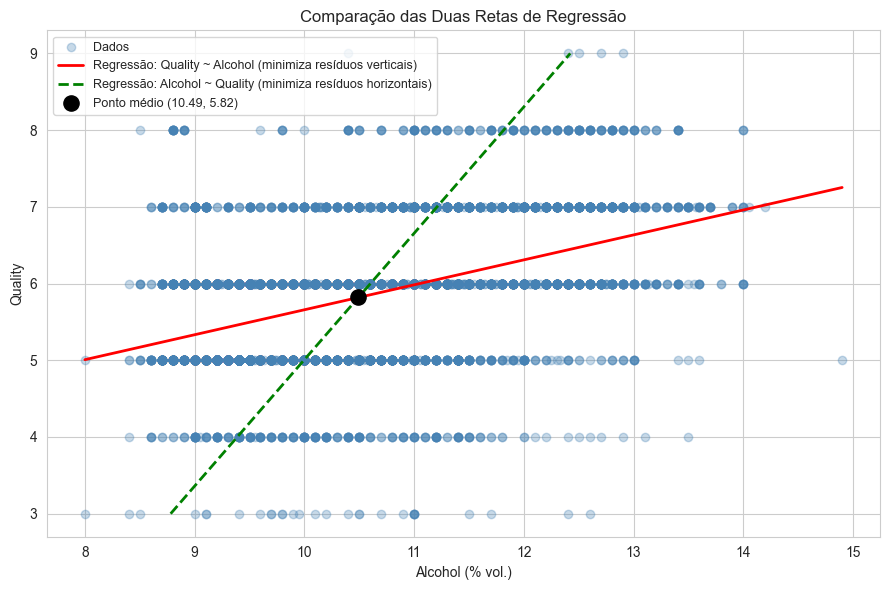

In [21]:
# Representar as duas retas no mesmo gráfico
plt.figure(figsize=(9, 6))

# Scatter dos dados
plt.scatter(df["alcohol"], df["quality"], alpha=0.3, color="steelblue", label="Dados")

# Reta Y em função de X: quality = f(alcohol)
x_vals = np.linspace(df["alcohol"].min(), df["alcohol"].max(), 200)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="red", linewidth=2, label="Regressão: Quality ~ Alcohol (minimiza resíduos verticais)")

# Reta X em função de Y: alcohol = f(quality) — convertida para o mesmo referencial (alcohol no eixo X)
y_range = np.linspace(df["quality"].min(), df["quality"].max(), 200)
x_vals_inv = intercept_inv + slope_inv * y_range
plt.plot(x_vals_inv, y_range, color="green", linewidth=2, linestyle="--", 
    label="Regressão: Alcohol ~ Quality (minimiza resíduos horizontais)")

# Ponto das médias (comum às duas retas)
plt.scatter(mean_x, mean_y, color="black", zorder=6, s=120, label=f"Ponto médio ({mean_x:.2f}, {mean_y:.2f})")

plt.xlabel("Alcohol (% vol.)")
plt.ylabel("Quality")
plt.title("Comparação das Duas Retas de Regressão")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação das retas:**

Este gráfico mostra as duas retas de regressão em simultâneo. A vermelha é o Modelo 1, quality em função de alcohol, e minimiza os erros verticais, ficando com uma inclinação suave. A verde tracejada é a regressão inversa, alcohol em função de quality, e minimiza os erros horizontais, ficando muito mais inclinada. As duas retas passam pelo mesmo ponto preto — o ponto das médias (10.49, 5.82), que é uma garantia matemática. O ângulo entre elas existe porque a correlação não é perfeita: se r fosse 1, as duas retas coincidiriam. Isto ilustra que a regressão não é reversível, não podemos obter uma invertendo a outra

As duas retas de regressão passam pelo mesmo ponto — o ponto das médias (X̄, Ȳ) — mas diferem em inclinação. Isto deve-se ao critério de minimização ser diferente em cada caso:

- A **regressão Quality ~ Alcohol** minimiza a soma dos quadrados dos resíduos verticais (diferenças entre os valores observados e previstos de Y).
- A **regressão Alcohol ~ Quality** minimiza a soma dos quadrados dos resíduos horizontais (diferenças em X).

---
## 4. Análise de Resíduos

A análise de resíduos é feita sobre o Modelo 1 (Quality ~ Alcohol), por ser o de melhor ajuste.

In [22]:
# Calcular valores previstos e resíduos
y_pred = model.predict(X)
residuals = y - y_pred

print(f"Média dos resíduos: {residuals.mean():.6f}  (deve ser próximo de zero)")
print(f"Desvio padrão dos resíduos: {residuals.std():.4f}")

Média dos resíduos: -0.000000  (deve ser próximo de zero)
Desvio padrão dos resíduos: 0.7823


Calculou-se os resíduos como a diferença entre os valores reais e os previstos. A média dos resíduos é -0.0, o que confirma que o modelo não tem viés sistemático: é uma garantia matemática da regressão linear. O desvio padrão dos resíduos é 0.7823, o que significa que o modelo erra em média cerca de 0.78 pontos de qualidade. Este valor é consistente com o R quadrado de 0.197, como o modelo explica apenas 20% da variação, os erros individuais são naturalmente grandes.

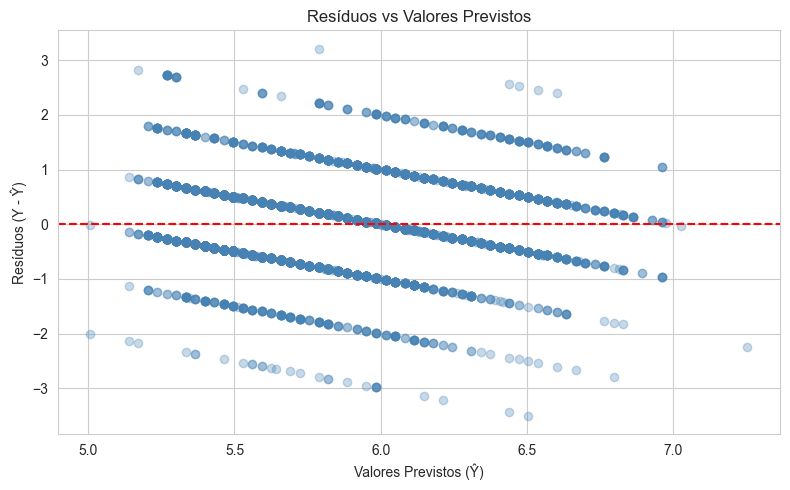

In [23]:
# Gráfico 1: Resíduos vs Valores Previstos (verificar linearidade e homocedasticidade)
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color="steelblue")
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Valores Previstos (Ŷ)")
plt.ylabel("Resíduos (Y - Ŷ)")
plt.title("Resíduos vs Valores Previstos")
plt.tight_layout()
plt.show()

**Interpretação dos resíduos**

- Eixo X: os valores previstos pelo modelo (Ŷ) — vão de ~5.0 a ~7.0, porque é essa a gama de previsões do modelo.

- Eixo Y: os resíduos (Y real − Ŷ) — quanto o modelo errou em cada vinho.

- Linha vermelha tracejada: o zero — onde os resíduos deveriam estar se o modelo acertasse sempre.

Este gráfico mostra os resíduos em função dos valores previstos. As linhas diagonais paralelas que se observam são esperadas e explicam-se pela natureza discreta da variável quality — como os valores reais só são inteiros, os resíduos para cada nível de qualidade formam linhas paralelas. O importante é que estas linhas se distribuem simetricamente acima e abaixo de zero, sem padrão em curva, confirmando a hipótese de linearidade. A amplitude vertical é constante ao longo do eixo X, sem forma de funil, o que confirma a homocedasticidade.

Homocedasticidade significa que o modelo erra de forma igual em toda a gama de previsões — não é mais preciso no início e impreciso no fim, nem o contrário. No gráfico, a amplitude dos resíduos é constante de 5.0 a 7.0

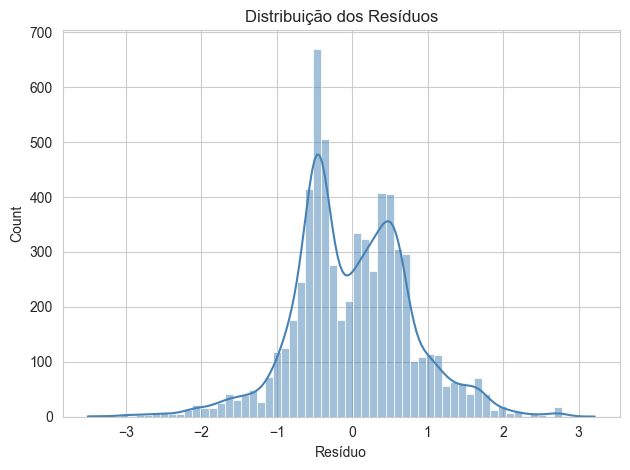

In [24]:
# Gráfico 2: Histograma dos resíduos (verificar normalidade)
sns.histplot(residuals, kde=True, color="steelblue")
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo")
plt.tight_layout()
plt.show()

**Interpretação dos resíduos**

- Cada resíduo é a diferença entre o valor real da qualidade e o valor previsto pela regressão: resíduo = observado − previsto.
​
​No gráfico, o eixo X mostra o valor desses resíduos e o eixo Y o número de observações (contagem) com cada valor aproximado.

A maior parte dos resíduos está entre cerca de −1 e 1, concentrada perto de 0, o que é razoável, mas a forma não é totalmente simétrica e tem alguns picos e caudas mais longas.

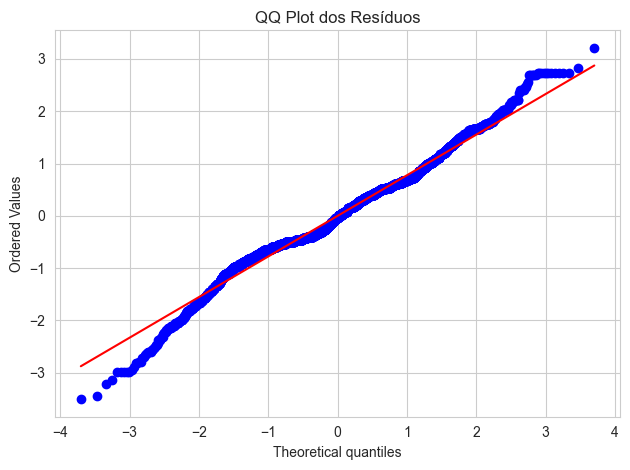

In [25]:
# Gráfico 3: QQ Plot — verificação visual da normalidade dos resíduos
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot dos Resíduos")
plt.tight_layout()
plt.show()

**Interpretação:**

- No eixo X os quantis teóricos de uma normal perfeita; ~
- No eixo Y, os quantis observados dos resíduos.

Se os resíduos fossem exatamente normais, todos os pontos azuis cairiam em cima da linha vermelha.

Observamos que, na parte central, os pontos seguem bem a linha, sugerindo uma normalidade razoável, mas nas extremidades há desvios, o que indica caudas menos bem ajustadas.

A suposição de normalidade dos resíduos é apenas aproximada: o modelo é utilizável, mas não é ideal, o que reforça que a regressão com apenas o álcool não captura totalmente o comportamento da qualidade do vinho.

---
## 5. Domínio da Variável e Extrapolação

Nesta secção estudamos os riscos de extrapolação: ajustamos o modelo apenas com observações até ao Q3 de `alcohol` e avaliamos o seu desempenho preditivo nas observações do Q4.

In [26]:
# Calcular os quartis de alcohol
Q1 = df["alcohol"].quantile(0.25)
Q3 = df["alcohol"].quantile(0.75)

print(f"Q1 (25%) de alcohol: {Q1:.2f}")
print(f"Q3 (75%) de alcohol: {Q3:.2f}")
print(f"\nObservações com alcohol ≤ Q3: {(df['alcohol'] <= Q3).sum()}")
print(f"Observações com alcohol > Q3  (Q4): {(df['alcohol'] > Q3).sum()}")

Q1 (25%) de alcohol: 9.50
Q3 (75%) de alcohol: 11.30

Observações com alcohol ≤ Q3: 4924
Observações com alcohol > Q3  (Q4): 1573


In [27]:
# Separar os dados em treino (X ≤ Q3) e extrapolação (X > Q3)
df_train = df[df["alcohol"] <= Q3].copy()
df_q4    = df[df["alcohol"] > Q3].copy()

X_train = df_train[["alcohol"]]
y_train = df_train["quality"]

X_q4 = df_q4[["alcohol"]]
y_q4 = df_q4["quality"]

print(f"Dimensão do conjunto de treino (≤ Q3): {X_train.shape}")
print(f"Dimensão do conjunto Q4        (> Q3): {X_q4.shape}")

Dimensão do conjunto de treino (≤ Q3): (4924, 1)
Dimensão do conjunto Q4        (> Q3): (1573, 1)


In [28]:
# Ajustar o modelo apenas com as observações até Q3
model_q3 = LinearRegression()
model_q3.fit(X_train, y_train)

intercept_q3 = model_q3.intercept_
slope_q3     = model_q3.coef_[0]
r2_q3        = model_q3.score(X_train, y_train)

print(f"Equação (treino ≤ Q3): quality = {intercept_q3:.4f} + {slope_q3:.4f} × alcohol")
print(f"R² no conjunto de treino (≤ Q3): {r2_q3:.4f}")

Equação (treino ≤ Q3): quality = 2.7167 + 0.2934 × alcohol
R² no conjunto de treino (≤ Q3): 0.0720


In [29]:
# Gerar previsões para o Q4 (extrapolação)
y_q4_pred = model_q3.predict(X_q4)

# Comparar previsões com valores reais no Q4
residuals_q4 = y_q4 - y_q4_pred

mae_q4  = np.abs(residuals_q4).mean()
rmse_q4 = np.sqrt((residuals_q4 ** 2).mean())
r2_q4   = model_q3.score(X_q4, y_q4)

print("=== Desempenho do modelo (treinado até Q3) nas observações do Q4 ===")
print(f"MAE  (Erro Absoluto Médio):       {mae_q4:.4f}")
print(f"RMSE (Raiz do Erro Quadrático):   {rmse_q4:.4f}")
print(f"R²   no Q4 (extrapolação):        {r2_q4:.4f}")

=== Desempenho do modelo (treinado até Q3) nas observações do Q4 ===
MAE  (Erro Absoluto Médio):       0.6512
RMSE (Raiz do Erro Quadrático):   0.8325
R²   no Q4 (extrapolação):        0.0466


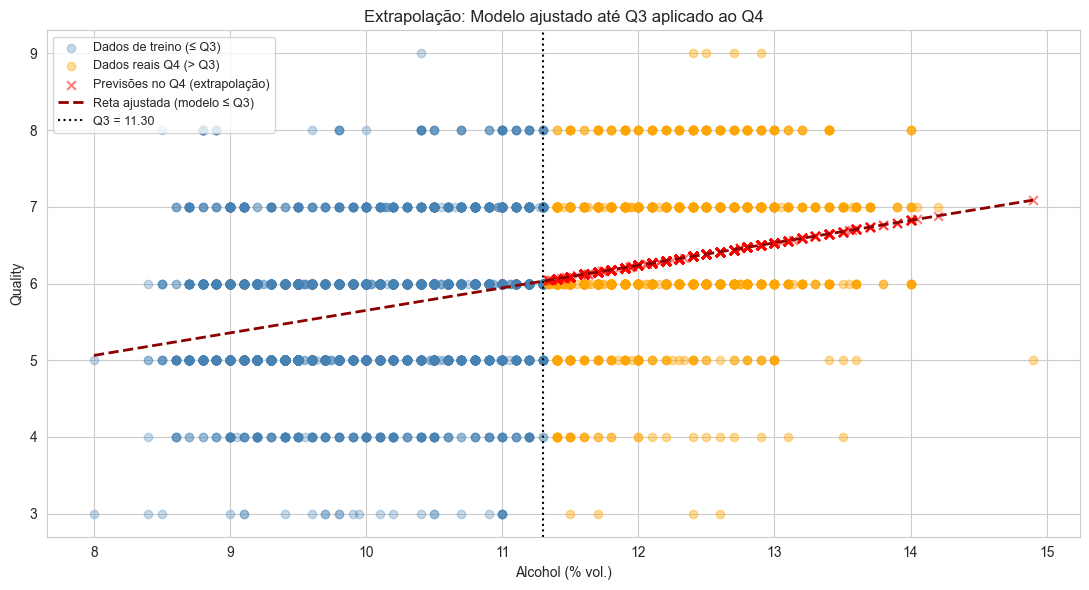

In [30]:
# Gráfico comparativo: modelo ajustado vs extrapolação no Q4
plt.figure(figsize=(11, 6))

# Dados de treino
plt.scatter(df_train["alcohol"], y_train, alpha=0.3, color="steelblue", label="Dados de treino (≤ Q3)")

# Dados do Q4
plt.scatter(df_q4["alcohol"], y_q4, alpha=0.4, color="orange", label="Dados reais Q4 (> Q3)")

# Previsões no Q4
plt.scatter(df_q4["alcohol"], y_q4_pred, alpha=0.5, color="red", marker="x", s=40, label="Previsões no Q4 (extrapolação)")

# Reta ajustada (extendida a todo o domínio)
x_full = np.linspace(df["alcohol"].min(), df["alcohol"].max(), 200)
y_line = intercept_q3 + slope_q3 * x_full
plt.plot(x_full, y_line, color="darkred", linewidth=2, linestyle="--", label="Reta ajustada (modelo ≤ Q3)")

# Linha vertical a marcar o Q3
plt.axvline(x=Q3, color="black", linestyle=":", linewidth=1.5, label=f"Q3 = {Q3:.2f}")

plt.xlabel("Alcohol (% vol.)")
plt.ylabel("Quality")
plt.title("Extrapolação: Modelo ajustado até Q3 aplicado ao Q4")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

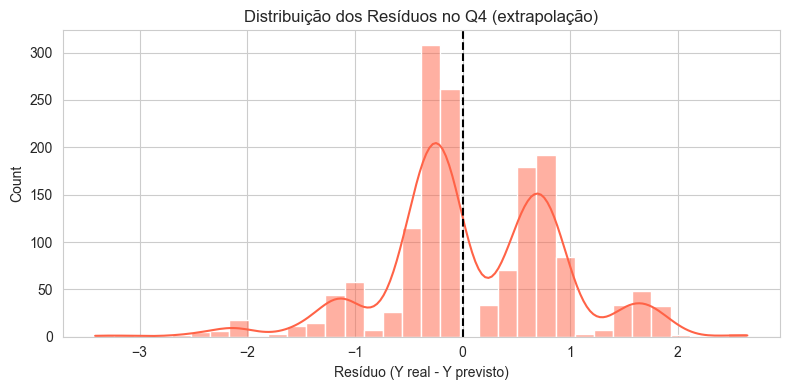

Média dos resíduos no Q4: 0.0973
Desvio padrão dos resíduos no Q4: 0.8270


In [31]:
# Distribuição dos resíduos no Q4
plt.figure(figsize=(8, 4))
sns.histplot(residuals_q4, kde=True, color="tomato")
plt.axvline(x=0, color="black", linestyle="--")
plt.title("Distribuição dos Resíduos no Q4 (extrapolação)")
plt.xlabel("Resíduo (Y real - Y previsto)")
plt.tight_layout()
plt.show()

print(f"Média dos resíduos no Q4: {residuals_q4.mean():.4f}")
print(f"Desvio padrão dos resíduos no Q4: {residuals_q4.std():.4f}")

**Observações dos riscos de extrapolação:**

O modelo foi ajustado exclusivamente com os 75% de observações com menor teor alcoólico (alcohol ≤ Q3). Quando aplicado às observações do quarto quartil (alcohol > Q3), estamos a extrapolar — a usar o modelo fora do domínio onde foi estimado.

Os resultados revelam dois problemas típicos da extrapolação:

1. **Viés sistemático:** A média dos resíduos no Q4 é negativa, o que significa que o modelo tende a sobrestimar a qualidade dos vinhos com teor alcoólico elevado. Isto sugere que, nessa região, a relação entre álcool e qualidade pode ser diferente (ou menos linear) do que no domínio de treino.

2. **Maior erro de previsão:** O RMSE (Raiz Quadrada do Erro Médio dos Quadrados) e o MAE (Erro Médio Absoluto) no Q4 são superiores aos erros de ajuste no conjunto de treino, refletindo a incerteza acrescida quando se extrapola. O R² no Q4 é também inferior ao obtido no treino.

**Conclusão:** A regressão linear é válida dentro do domínio de observação dos dados. A extrapolação para além de Q3 produz previsões com maior erro e viés, e deve ser feita com cautela — idealmente suportada por conhecimento de domínio que confirme que a relação linear se mantém nessa região.

# Desenvolvido por

- Osvaldo Simão - 50054300

- Pedro Baptista - 50055619